# 04 - Rate of descent: gliding flight, powered descent and drift-down

References: Roskam & Lan, Sec. 8.2 (steady un-powered flight), Secs. 9.2.3,
9.3.3 and 9.4.2 (drift-down); Anderson, Sec. 5.11.

In [1]:
# --- Setup -------------------------------------------------------------------
# The notebooks live in PrestazioniRoskam/, one level below the repository root,
# where the `aircraft_performance` package is. Make it importable:
import sys
import pathlib
ROOT = pathlib.Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

import aircraft_performance as ap
from aircraft_performance import units as u
from aircraft_performance.atmosphere import isa
from aircraft_performance.plotting import apply_style, reference_line
from aircraft_performance.reporting import print_table

apply_style()
print(f"aircraft_performance v{ap.__version__} ready")

from aircraft_performance import descent, climb, aerodynamics as aero
from aircraft_performance.aerodynamics import ParabolicDragPolar

single = ap.examples.light_single_piston()
atr = ap.examples.regional_turboprop()
jet = ap.examples.business_jet_giv()

aircraft_performance v1.0.0 ready


## 1. Steady glide: equations

With $T=0$ the aerodynamic resultant balances the weight (Roskam Eqns 8.8-8.16).
Calling $\bar\gamma>0$ the glide angle below the horizon:

$$
D = W\sin\bar\gamma,\quad L = W\cos\bar\gamma
\;\Rightarrow\;
\tan\bar\gamma = \frac{C_D}{C_L},\qquad
V = \sqrt{\frac{2W}{\rho S\sqrt{C_L^2+C_D^2}}},\qquad
RD = V\sin\bar\gamma
$$

For small angles ($\cos\bar\gamma\approx1$, error < 5 % up to 18°):

$$
RD \approx \sqrt{\frac{2W}{\rho S}}\;\frac{C_D}{C_L^{3/2}}
$$

| goal | condition | polar point | result |
|---|---|---|---|
| longest distance | min $\bar\gamma$ | E, max $C_L/C_D$ | $\tan\bar\gamma_{min}=1/E_{max}$, $R_{max}=h\,E_{max}$ (Eqns 8.27-8.28) |
| longest time | min $RD$ | P, max $C_L^3/C_D^2$ | Eqns 8.30-8.31 |
| minimum speed | max $C_L$ | stall | Eqn 8.32 |

The glide *distance* depends only on the polar: it is independent of weight and
altitude. The *speeds* scale with $\sqrt{W/(\rho S)}$.

## 2. Roskam's glider (Table 8.1 and Figs. 8.4-8.5)

Roskam's glider: $W = 300$ kg, $S = 14.1$ m$^2$, $b = 15$ m, approximated by a
parabolic polar with $A = 15.6$, $e = 0.82$, $C_{D_0} = 0.015$ (p. 341). The table
below is the analogue of Roskam Table 8.1, obtained from the parabolic fit.

In [2]:
W_g, S_g = 300 * u.G0, 14.1
glider = ParabolicDragPolar.from_aspect_ratio(0.015, 15.6, 0.82, name="glider")
rho0 = isa(0.0).density
CLs = np.array([0.12, 0.25, 0.49, 0.70, 0.90, 1.08, 1.23, 1.36, 1.46])
rows = []
for CL in CLs:
    s = descent.glide_state(W_g, S_g, rho0, CL, glider)
    rows.append([CL, s.CD, CL / s.CD, CL**3 / s.CD**2, s.gamma_deg, s.V, s.V * 3.6, s.sink_rate])
print_table(["CL", "CD", "CL/CD", "CL^3/CD^2", "gamma [deg]", "V [m/s]", "V [km/h]", "RD [m/s]"], rows,
            ["{:.2f}", "{:.4f}", "{:.1f}", "{:.0f}", "{:.2f}", "{:.1f}", "{:.1f}", "{:.2f}"])
bg = descent.best_glide(W_g, S_g, rho0, glider)
print(f"\nBest glide speed at sea level: {bg.V:.1f} m/s (Roskam, p. 341: 20.9 m/s)")

  CL      CD  CL/CD  CL^3/CD^2  gamma [deg]  V [m/s]  V [km/h]  RD [m/s]
----  ------  -----  ---------  -----------  -------  --------  --------
0.12  0.0154    7.8          7         7.29     53.1     191.0      6.74
0.25  0.0166   15.1         57         3.79     36.9     132.7      2.44
0.49  0.0210   23.4        267         2.45     26.4      94.9      1.13
0.70  0.0272   25.7        464         2.22     22.1      79.4      0.86
0.90  0.0352   25.6        590         2.24     19.4      70.0      0.76
1.08  0.0440   24.5        650         2.33     17.8      63.9      0.72
1.23  0.0526   23.4        671         2.45     16.6      59.9      0.71
1.36  0.0610   22.3        675         2.57     15.8      56.9      0.71
1.46  0.0680   21.5        672         2.67     15.3      55.0      0.71

Best glide speed at sea level: 20.9 m/s (Roskam, p. 341: 20.9 m/s)


## 3. The hodograph (speed polar)

Plotting the vertical speed $RD$ against the horizontal speed $V\cos\bar\gamma$
gives the **hodograph** (Roskam Figs. 8.7-8.9):

* the tangent from the origin touches the curve at the **best glide** point (E);
* the highest point is the **minimum sink** point (P);
* at a given angle of attack, changing altitude or weight moves the point along
  a straight line through the origin, scaling speeds by $\sqrt{\rho_1/\rho_2}$ or
  $\sqrt{W_2/W_1}$ (Eqns 8.34-8.35).

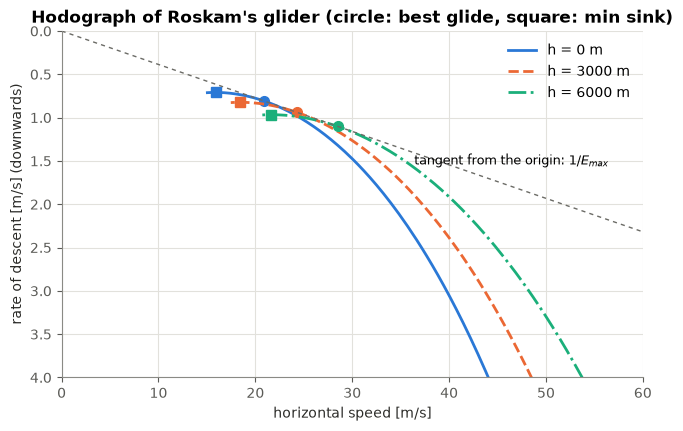

In [3]:
CLs = np.linspace(0.12, 1.5, 200)
fig, ax = plt.subplots()
for h in (0.0, 3000.0, 6000.0):
    hp = descent.glide_polar(W_g, S_g, isa(h).density, glider, CLs)
    line, = ax.plot(hp["V_horizontal"], hp["sink_rate"], label=f"h = {h:.0f} m")
    E = descent.best_glide(W_g, S_g, isa(h).density, glider)
    P = descent.minimum_sink(W_g, S_g, isa(h).density, glider)
    ax.plot(E.horizontal_speed, E.sink_rate, "o", color=line.get_color())
    ax.plot(P.horizontal_speed, P.sink_rate, "s", color=line.get_color())
xg = np.array([0, 60])
ax.plot(xg, xg / glider.max_lift_to_drag, color="#6b6b66", linewidth=1, linestyle=(0, (3, 3)))
ax.annotate("tangent from the origin: $1/E_{max}$", (45, 45 / glider.max_lift_to_drag), xytext=(-60, 12),
            textcoords="offset points", fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 60); ax.set_ylim(4, 0)
ax.set_xlabel("horizontal speed [m/s]"); ax.set_ylabel("rate of descent [m/s] (downwards)")
ax.set_title("Hodograph of Roskam's glider (circle: best glide, square: min sink)")
ax.legend()
plt.show()

## 4. Engine failure: the business jet as a glider (Anderson Examples 5.14-5.15)

In [4]:
h0 = 30000 * u.FT
rho = isa(h0).density
bg = descent.best_glide(jet.weight, jet.wing_area, rho, jet.polar())
ms = descent.minimum_sink(jet.weight, jet.wing_area, rho, jet.polar())
print_table(["quantity", "this code", "Anderson"],
            [["min glide angle [deg]", bg.gamma_deg, 3.964],
             ["max glide distance from 30,000 ft [ft]", descent.max_glide_distance(h0, jet.polar()) / u.FT, 432900],
             ["best-glide speed at 30,000 ft [ft/s]", bg.V / u.FT, 631.2],
             ["sink rate at best glide [ft/s]", bg.sink_rate / u.FT, 43.6],
             ["minimum sink rate [ft/s]", ms.sink_rate / u.FT, 38.6]],
            ["{}", "{:.3f}", "{:.3f}"])

                              quantity   this code    Anderson
--------------------------------------  ----------  ----------
                 min glide angle [deg]       3.963       3.964
max glide distance from 30,000 ft [ft]  433012.702  432900.000
  best-glide speed at 30,000 ft [ft/s]     630.997     631.200
        sink rate at best glide [ft/s]      43.612      43.600
              minimum sink rate [ft/s]      38.219      38.600


The small difference in the minimum sink rate comes from Anderson's use of the
small-angle expression with the rounded value $(C_L^{3/2}/C_D)_{max}=10.83$.

### Time aloft: why density matters

Eqn (8.31) estimates the time aloft as $h/RD_{min}$ using a single density.
Since $RD\propto1/\sqrt\rho$, the sink rate *decreases* while the aircraft
descends into denser air. Integrating $t=\int dh/RD(h)$ (the task of Roskam
Problem 8.5) therefore gives a **longer** time than the estimate made with the
starting-altitude density - and a shorter one than an estimate made with
sea-level density. (Roskam's remark on p. 341 that the actual time "will be
somewhat less" holds with respect to a sea-level-density estimate, not a
starting-altitude one.)

In [5]:
rows = []
for h_start in (1000.0, 3000.0, 6000.0):
    t_int = descent.glide_time(single.weight, single.wing_area, single.polar(), h_start)
    t_top = descent.glide_time_constant_density(single.weight, single.wing_area, isa(h_start).density,
                                                single.polar(), h_start)
    t_sl = descent.glide_time_constant_density(single.weight, single.wing_area, isa(0.0).density,
                                               single.polar(), h_start)
    rows.append([h_start, t_top / 60, t_int / 60, t_sl / 60, descent.max_glide_distance(h_start, single.polar()) / 1000])
print(f"{single.name}, engine failure, gliding at minimum sink / best glide")
print_table(["h start [m]", "t (rho at start) [min]", "t integrated [min]", "t (rho sea level) [min]",
             "max glide distance [km]"], rows, ["{:.0f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.1f}"])

Light single-engine piston (C172-like), engine failure, gliding at minimum sink / best glide
h start [m]  t (rho at start) [min]  t integrated [min]  t (rho sea level) [min]  max glide distance [km]
-----------  ----------------------  ------------------  -----------------------  -----------------------
       1000                    6.00                6.15                     6.30                     12.6
       3000                   16.28               17.58                    18.90                     37.8
       6000                   27.74               32.64                    37.81                     75.5


## 5. Effect of wind: the speed to fly (Roskam Sec. 8.2.4.4)

Wind moves the origin of the hodograph (Roskam Figs. 8.13-8.14): a headwind
shifts it along the positive horizontal axis, a sinking air mass along the
positive $RD$ axis. The tangent from the *new* origin gives the speed that
maximises the distance over the ground: **fly faster in a headwind or in
sinking air, slower in a tailwind or in rising air**.

In [6]:
rho = isa(1000.0).density
args = (single.weight, single.wing_area, rho, single.polar(), single.config().CL_max)
rows = []
for hw, wz, label in ((0, 0, "still air"), (10, 0, "headwind 10 m/s"), (-10, 0, "tailwind 10 m/s"),
                      (0, -1.5, "sinking air 1.5 m/s"), (0, 1.0, "rising air 1 m/s")):
    r = descent.best_glide_with_wind(*args, headwind=hw, updraft=wz)
    rows.append([label, r["state"].V, r["ground_speed"], r["ground_glide_ratio"]])
print(f"{single.name}: best speed to fly at 1,000 m")
print_table(["condition", "airspeed [m/s]", "ground speed [m/s]", "ground glide ratio"], rows,
            ["{}", "{:.1f}", "{:.1f}", "{:.2f}"])

Light single-engine piston (C172-like): best speed to fly at 1,000 m
          condition  airspeed [m/s]  ground speed [m/s]  ground glide ratio
-------------------  --------------  ------------------  ------------------
          still air            40.0                39.9               12.59
    headwind 10 m/s            43.2                33.0                9.55
    tailwind 10 m/s            38.0                47.8               15.82
sinking air 1.5 m/s            44.5                44.3                8.69
   rising air 1 m/s            36.7                36.6               18.76


## 6. Powered descent

With thrust the rate of descent is (Roskam Eqns 9.18-9.20)

$$
RD = \frac{(D-T)\,V}{W} = \frac{P_{req}-P_{av}}{W}
$$

A typical airliner descent is flown at idle thrust and constant (calibrated)
airspeed. `descent.descent_at_constant_eas` integrates it; with idle thrust the
jet's fuel flow is zero in this simple model (a real engine burns idle fuel).

Business jet (Gulfstream IV-like): idle descent 11,000 m -> 1,000 m at 272 KEAS
  time 10.5 min, distance 120 km, mean descent gradient 8.4 %


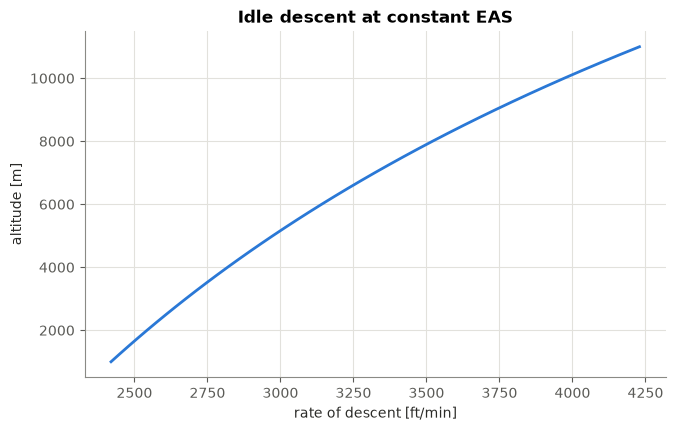

In [7]:
V_eas = 140.0      # m/s (~272 KEAS)
prof = descent.descent_at_constant_eas(jet, 11000.0, 1000.0, V_eas, weight=0.75 * jet.weight)
print(f"{jet.name}: idle descent 11,000 m -> 1,000 m at {V_eas / u.KT:.0f} KEAS")
print(f"  time {prof.total_time/60:.1f} min, distance {prof.total_distance/1000:.0f} km, "
      f"mean descent gradient {100 * 10000 / prof.total_distance:.1f} %")
fig, ax = plt.subplots()
ax.plot(prof.rate_of_descent / u.FPM, prof.altitude)
ax.set_xlabel("rate of descent [ft/min]"); ax.set_ylabel("altitude [m]")
ax.set_title("Idle descent at constant EAS")
plt.show()

The rate of descent increases with altitude because, at constant EAS, the true
airspeed (and $P_{req}=DV$) grows as $1/\sqrt\sigma$. With zero thrust the descent
gradient is simply $1/(L/D)$ at the flown speed: here the jet descends at 272
KEAS, well above its best-glide speed ($C_L\approx0.23$ against $C_{L_E}=0.43$),
so $L/D\approx12$ and the gradient is about 8 %. The airline "3-to-1" rule of
thumb (3 nm per 1,000 ft, about 5.5 %) corresponds to $L/D\approx18$, typical of
modern airliners flown near best glide (see exercise 4).

## 7. One engine inoperative: drift-down (Roskam Sec. 9.4.2)

A twin cruising above its one-engine-inoperative (OEI) ceiling must descend
("drift down") after an engine failure. The procedure of Roskam Table 9.8:

1. at each altitude, fly at the speed of **minimum rate of descent** with the
   remaining engine at maximum continuous power (the windmilling engine and the
   trim add drag, here $\Delta C_{D_0} = 0.005$);
2. never descend slower than 100 ft/min (near the OEI ceiling the minimum
   $RD$ tends to zero and the time would be infinite);
3. stop at the **OEI ceiling** (RC = 100 ft/min).

Regional turboprop (ATR 72-like): OEI service ceiling 2761 m, absolute 3471 m


Drift-down from 7500 m to 2761 m: 88.8 min, 398 km, fuel 586 kg


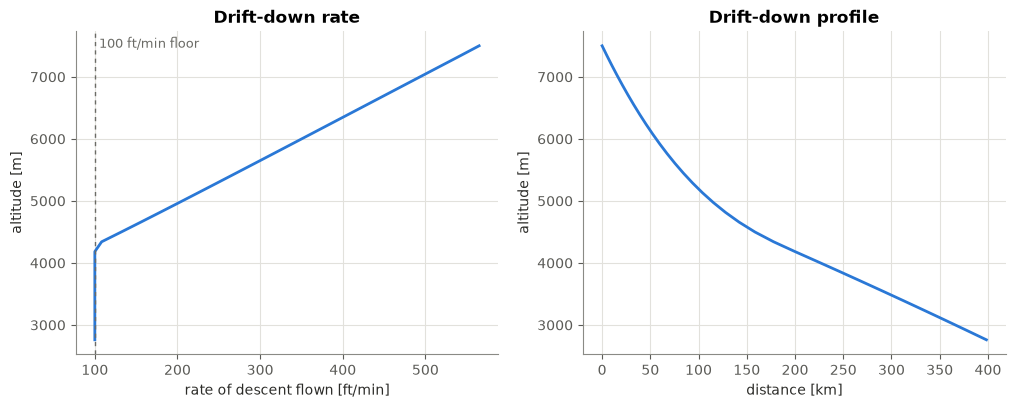

In [8]:
h_cruise = 7500.0
W = 0.95 * atr.weight
oei = climb.ceilings(atr, weight=W, n_operative=1, extra_CD0=0.005)
print(f"{atr.name}: OEI service ceiling {oei.service:.0f} m, absolute {oei.absolute:.0f} m")
dd = descent.drift_down(atr, h_cruise, weight=W, extra_CD0=0.005)
print(f"Drift-down from {h_cruise:.0f} m to {dd.final_altitude:.0f} m: {dd.total_time/60:.1f} min, "
      f"{dd.total_distance/1000:.0f} km, fuel {dd.total_fuel_weight/u.G0:.0f} kg")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.plot(dd.rate_of_descent / u.FPM, dd.altitude)
reference_line(a1, 100, label="100 ft/min floor")
a1.set_xlabel("rate of descent flown [ft/min]"); a1.set_ylabel("altitude [m]"); a1.set_title("Drift-down rate")
a2.plot(dd.distance / 1000, dd.altitude)
a2.set_xlabel("distance [km]"); a2.set_ylabel("altitude [m]"); a2.set_title("Drift-down profile")
plt.show()

The drift-down distance is essential for flights over mountains (terrain
clearance) and for ETOPS planning over water (Roskam p. 416).

## 8. Exercises

1. Compute the best-glide speed of the light single at 3,000 m for 900 kg and
   1,100 kg. Check that the ratio is $\sqrt{1100/900}$ and that the glide angle
   does not change.
2. With speed brakes ($\Delta C_{D_0} = 0.05$) at 1,000 ft and 100 kt, compute the
   glide angle and rate of descent of the jet (Roskam Problem 8.10).
3. Repeat the drift-down for an ISA+20 day.
4. Find the EAS that minimises the descent gradient of the jet and compare the
   distance covered from 11,000 m with the one computed above.